In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy import stats
import joblib, os, json, time

# Global style
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.edgecolor": "#333333",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "savefig.bbox": "tight",
})

PALETTE = {
    "primary":  "#2c7fb8",
    "accent":   "#e6550d",
    "success":  "#31a354",
    "danger":   "#d62728",
    "warning":  "#fec44f",
    "neutral":  "#636363",
    "purple":   "#756bb1",
}

os.makedirs("../figures/regression", exist_ok=True)
os.makedirs("../models", exist_ok=True)
print("Setup complete.")

Setup complete.


In [2]:
from sklearn.preprocessing import StandardScaler

train = pd.read_parquet("../data/processed/train.parquet")
val   = pd.read_parquet("../data/processed/val.parquet")
test  = pd.read_parquet("../data/processed/test.parquet")

with open("../models/feature_cols.json") as f:
    meta = json.load(f)
feature_cols = meta["features"]
target_col   = meta["target"]

# --- FIX: add current value of target + PUE as features ---
extra_cols = ["avg_return_temp", "pue"]
extra_scaler = StandardScaler().fit(train[extra_cols])

train[extra_cols] = extra_scaler.transform(train[extra_cols])
val[extra_cols]   = extra_scaler.transform(val[extra_cols])
test[extra_cols]  = extra_scaler.transform(test[extra_cols])

feature_cols = feature_cols + extra_cols

print(f"Train: {train.shape}  Val: {val.shape}  Test: {test.shape}")
print(f"Base features: {len(meta['features'])}")
print(f"Added features: {extra_cols}")
print(f"Extended feature set: {len(feature_cols)} features")
print(f"Target: {target_col}")

Train: (34541, 48)  Val: (7402, 48)  Test: (7402, 48)
Base features: 39
Added features: ['avg_return_temp', 'pue']
Extended feature set: 41 features
Target: avg_return_temp


In [3]:
# Reload the original scaler and target column in °C
scaler = joblib.load("../models/scaler.pkl")
target_idx = feature_cols.index("avg_return_temp") - len(extra_cols)  # position in original feature_cols
# Note: avg_return_temp is not in original feature_cols, so this is unused.

# Simpler: pull raw target value directly from the parquet using the extra_scaler inverse
def add_regression_target(df):
    df = df.copy()
    # Unscale avg_return_temp back to °C using the extra_scaler
    raw_temp = extra_scaler.inverse_transform(df[["avg_return_temp","pue"]])[:, 0]
    df["y_next"] = pd.Series(raw_temp, index=df.index).shift(-1)
    return df.dropna(subset=["y_next"])

train_r = add_regression_target(train)
val_r   = add_regression_target(val)
test_r  = add_regression_target(test)

print(f"Train: {len(train_r):,}  Val: {len(val_r):,}  Test: {len(test_r):,}")
print(f"Target range (train): {train_r['y_next'].min():.2f} – {train_r['y_next'].max():.2f} °C")
print(f"Target mean ± std   : {train_r['y_next'].mean():.2f} ± {train_r['y_next'].std():.2f} °C")

Train: 34,540  Val: 7,401  Test: 7,401
Target range (train): 7.65 – 45.62 °C
Target mean ± std   : 31.01 ± 4.78 °C


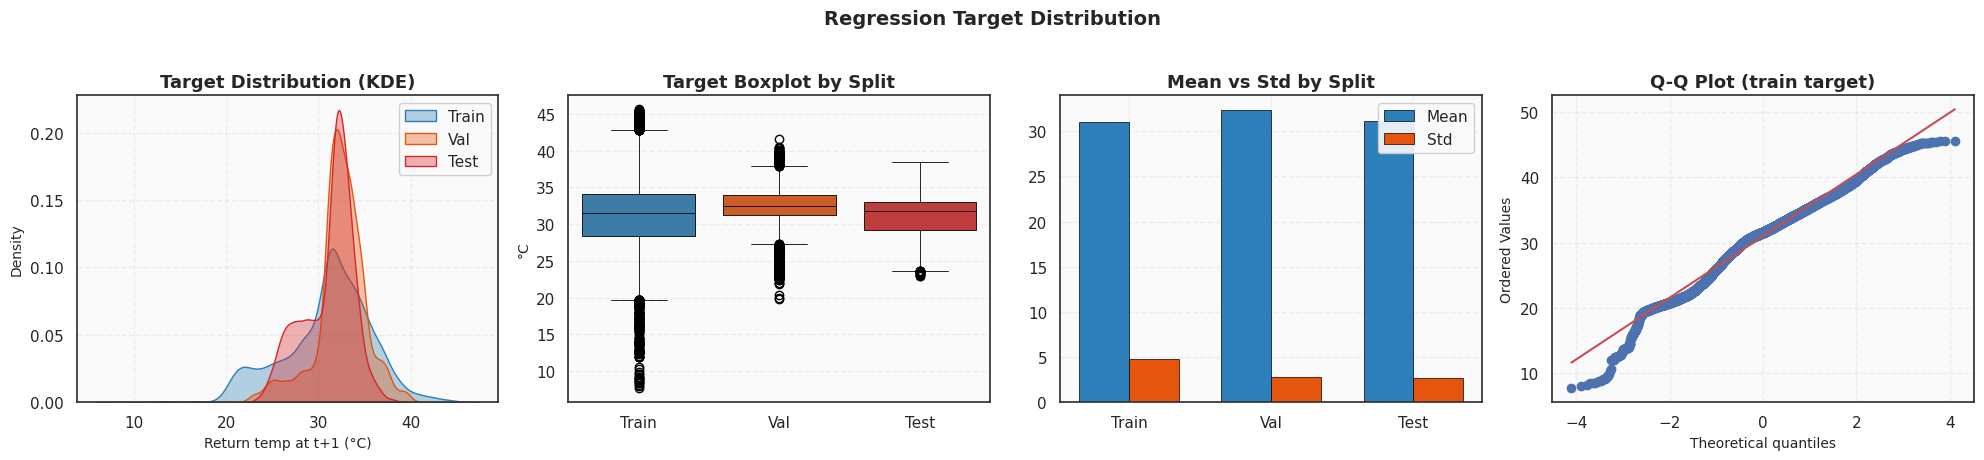

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

# KDE overlay
for name, d, c in [("Train", train_r, PALETTE["primary"]),
                   ("Val",   val_r,   PALETTE["accent"]),
                   ("Test",  test_r,  PALETTE["danger"])]:
    sns.kdeplot(d["y_next"], ax=axes[0], fill=True, alpha=0.35,
                color=c, label=name)
axes[0].set_title("Target Distribution (KDE)")
axes[0].set_xlabel("Return temp at t+1 (°C)")
axes[0].legend()

# Boxplot — use linecolor instead of edgecolor
box_data = pd.DataFrame({
    "Train": train_r["y_next"], "Val": val_r["y_next"], "Test": test_r["y_next"]
})
sns.boxplot(data=box_data, ax=axes[1],
            palette=[PALETTE["primary"], PALETTE["accent"], PALETTE["danger"]],
            linecolor="black", linewidth=0.6)
axes[1].set_title("Target Boxplot by Split")
axes[1].set_ylabel("°C")

# Mean/std bar
stats_df = pd.DataFrame({
    "split": ["Train", "Val", "Test"],
    "mean":  [train_r["y_next"].mean(), val_r["y_next"].mean(), test_r["y_next"].mean()],
    "std":   [train_r["y_next"].std(),  val_r["y_next"].std(),  test_r["y_next"].std()],
})
x = np.arange(3); w = 0.35
axes[2].bar(x - w/2, stats_df["mean"], w, label="Mean", color=PALETTE["primary"],
            edgecolor="black", linewidth=0.5)
axes[2].bar(x + w/2, stats_df["std"],  w, label="Std",  color=PALETTE["accent"],
            edgecolor="black", linewidth=0.5)
axes[2].set_xticks(x); axes[2].set_xticklabels(stats_df["split"])
axes[2].set_title("Mean vs Std by Split")
axes[2].legend()

# QQ plot for train
stats.probplot(train_r["y_next"], dist="norm", plot=axes[3])
axes[3].set_title("Q-Q Plot (train target)")

plt.suptitle("Regression Target Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../figures/regression/01_target_distribution.png", dpi=150)
plt.show()

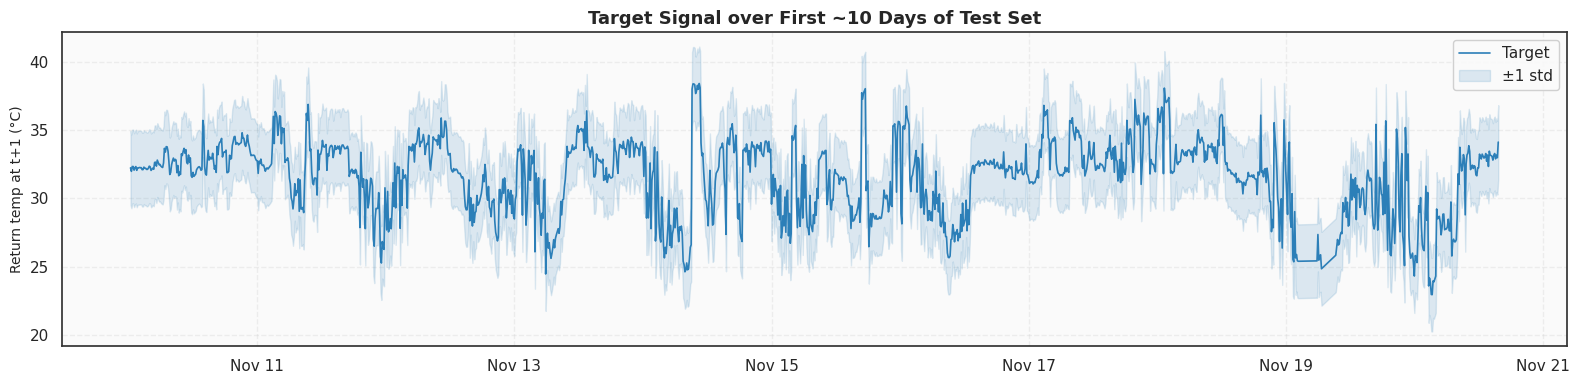

In [5]:
fig, ax = plt.subplots(figsize=(16, 4))
zoom = test_r.iloc[:1500]

ax.plot(zoom["timestamp"], zoom["y_next"], lw=1.2,
        color=PALETTE["primary"], label="Target")
ax.fill_between(zoom["timestamp"],
                zoom["y_next"] - zoom["y_next"].std(),
                zoom["y_next"] + zoom["y_next"].std(),
                alpha=0.15, color=PALETTE["primary"], label="±1 std")

ax.set_title("Target Signal over First ~10 Days of Test Set")
ax.set_ylabel("Return temp at t+1 (°C)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend()
plt.tight_layout()
plt.savefig("../figures/regression/02_target_over_time.png", dpi=150)
plt.show()

In [6]:
X_train, y_train = train_r[feature_cols].values, train_r["y_next"].values
X_val,   y_val   = val_r[feature_cols].values,   val_r["y_next"].values
X_test,  y_test  = test_r[feature_cols].values,  test_r["y_next"].values

regressors = {
    "LinearRegression": LinearRegression(),
    "Ridge":            Ridge(alpha=1.0, random_state=42),
    "RandomForest":     RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42),
    "XGBoost":          XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                                     random_state=42, n_jobs=-1),
    "LightGBM":         LGBMRegressor(n_estimators=500, learning_rate=0.05,
                                      random_state=42, n_jobs=-1, verbose=-1),
}

reg_results = {}
for name, reg in regressors.items():
    t0 = time.time()
    reg.fit(X_train, y_train)
    train_time = time.time() - t0
    preds = reg.predict(X_test)

    resid = y_test - preds
    reg_results[name] = {
        "model":       reg,
        "preds":       preds,
        "residuals":   resid,
        "MAE":         mean_absolute_error(y_test, preds),
        "RMSE":        np.sqrt(mean_squared_error(y_test, preds)),
        "R2":          r2_score(y_test, preds),
        "MAPE":        np.mean(np.abs(resid / y_test)) * 100,
        "train_time":  train_time,
    }
    print(f"{name:18s}  MAE={reg_results[name]['MAE']:.4f}  "
          f"RMSE={reg_results[name]['RMSE']:.4f}  "
          f"R²={reg_results[name]['R2']:.4f}  "
          f"({train_time:.1f}s)")

LinearRegression    MAE=1.1853  RMSE=1.6839  R²=0.6219  (0.2s)
Ridge               MAE=1.1835  RMSE=1.6803  R²=0.6235  (0.1s)
RandomForest        MAE=1.8960  RMSE=2.6240  R²=0.0818  (55.0s)
XGBoost             MAE=1.8695  RMSE=2.7047  R²=0.0244  (3.5s)
LightGBM            MAE=1.8105  RMSE=2.6587  R²=0.0574  (2.1s)


                     MAE    RMSE      R²  MAPE (%)  Train time (s)
LinearRegression  1.1853  1.6839  0.6219    3.8229            0.19
Ridge             1.1835  1.6803  0.6235    3.8159            0.07
RandomForest      1.8960  2.6240  0.0818    6.2847           54.96
XGBoost           1.8695  2.7047  0.0244    6.1087            3.47
LightGBM          1.8105  2.6587  0.0574    5.8960            2.11


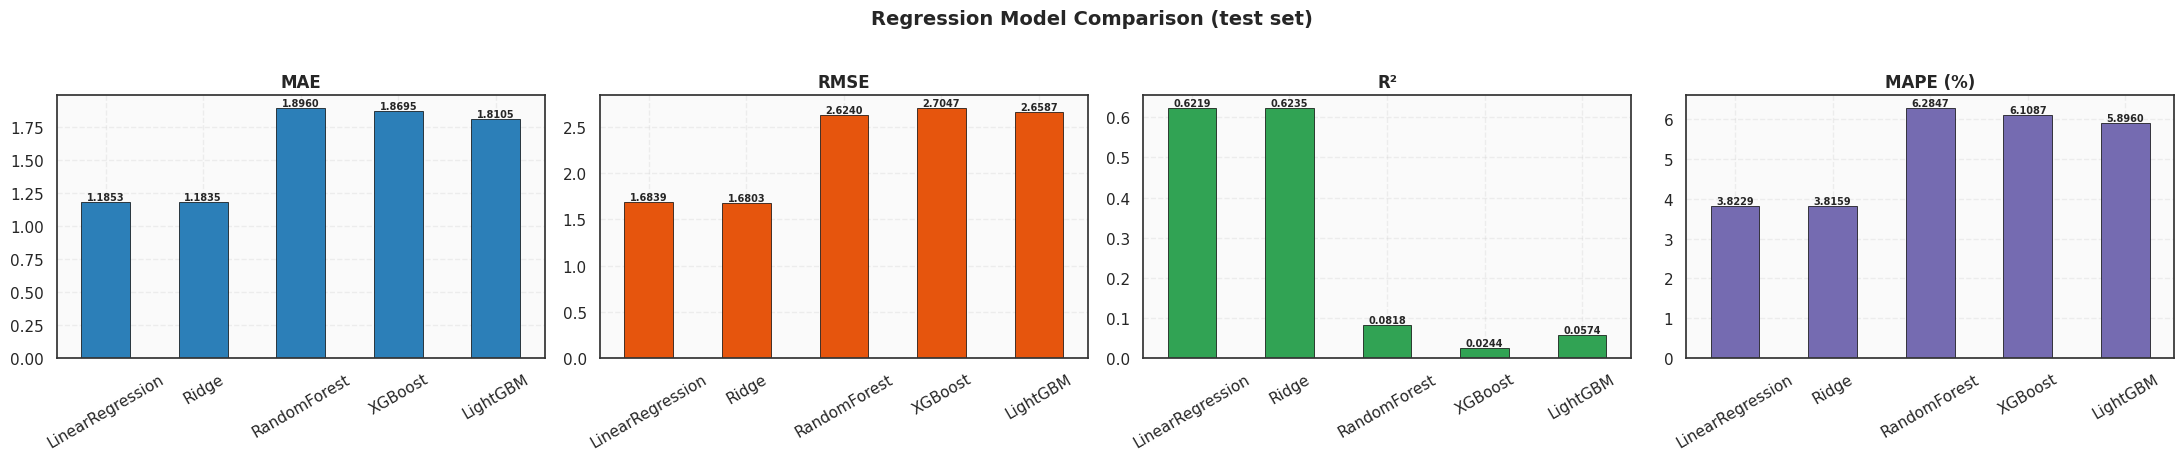

In [7]:
df_reg = pd.DataFrame({
    name: {
        "MAE":          r["MAE"],
        "RMSE":         r["RMSE"],
        "R²":           r["R2"],
        "MAPE (%)":     r["MAPE"],
        "Train time (s)": round(r["train_time"], 2),
    }
    for name, r in reg_results.items()
}).T.round(4)

print(df_reg)

metrics = ["MAE", "RMSE", "R²", "MAPE (%)"]
colors  = [PALETTE["primary"], PALETTE["accent"], PALETTE["success"], PALETTE["purple"]]

fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
for ax, m, c in zip(axes, metrics, colors):
    df_reg[m].plot(kind="bar", ax=ax, color=c, edgecolor="black", linewidth=0.5)
    ax.set_title(m, fontsize=12)
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(df_reg[m]):
        ax.text(i, v, f"{v:.4f}", ha="center", va="bottom",
                fontsize=7, fontweight="bold")

plt.suptitle("Regression Model Comparison (test set)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../figures/regression/03_comparison.png", dpi=150)
plt.show()

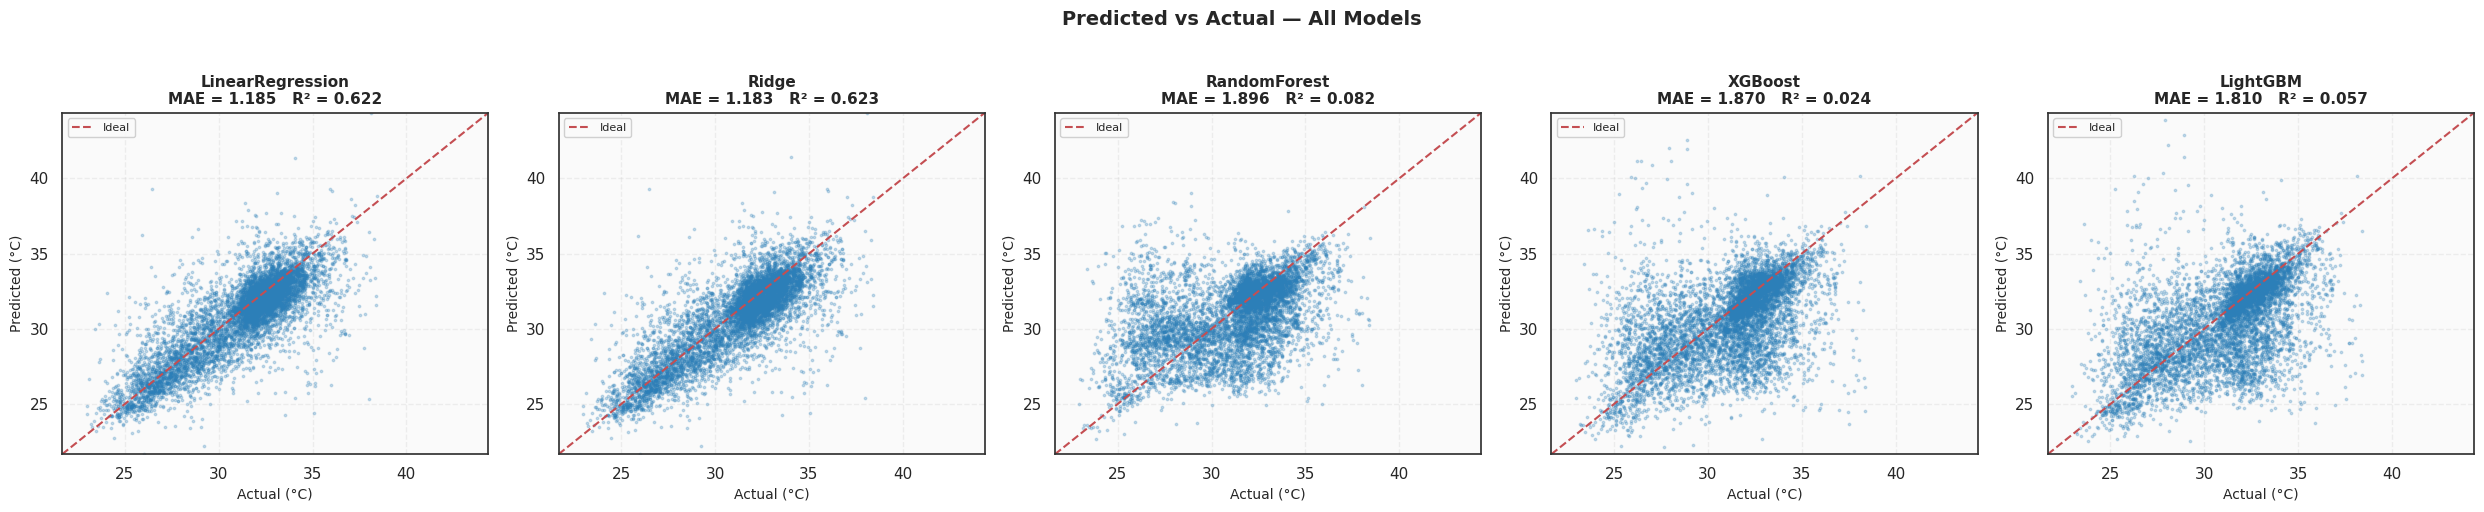

In [8]:
fig, axes = plt.subplots(1, len(reg_results), figsize=(5*len(reg_results), 5))

lims = [min(y_test.min(), min(r["preds"].min() for r in reg_results.values())),
        max(y_test.max(), max(r["preds"].max() for r in reg_results.values()))]

for ax, (name, r) in zip(axes, reg_results.items()):
    ax.scatter(y_test, r["preds"], s=3, alpha=0.25, color=PALETTE["primary"])
    ax.plot(lims, lims, "r--", lw=1.5, label="Ideal")
    ax.set_xlabel("Actual (°C)")
    ax.set_ylabel("Predicted (°C)")
    ax.set_title(f"{name}\nMAE = {r['MAE']:.3f}   R² = {r['R2']:.3f}",
                 fontsize=11)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.legend(loc="upper left", fontsize=8)

plt.suptitle("Predicted vs Actual — All Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../figures/regression/04_pred_vs_actual.png", dpi=150)
plt.show()

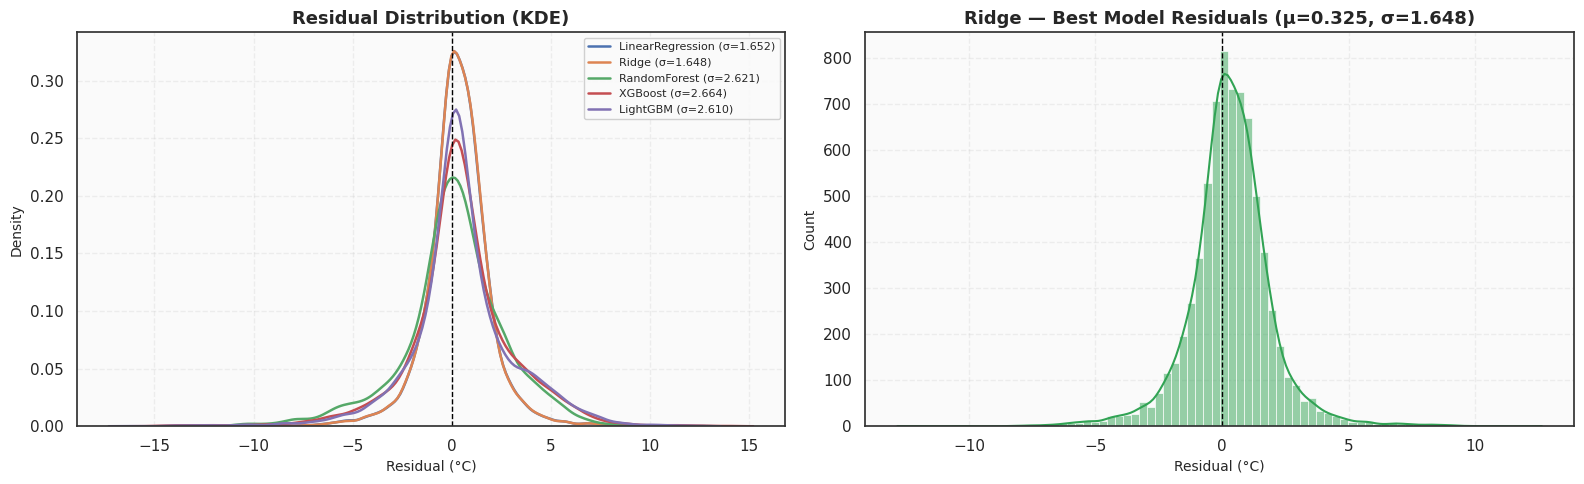

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KDE overlay
for name, r in reg_results.items():
    sns.kdeplot(r["residuals"], ax=axes[0], lw=1.8, label=f"{name} (σ={r['residuals'].std():.3f})")
axes[0].axvline(0, color="black", ls="--", lw=1)
axes[0].set_xlabel("Residual (°C)")
axes[0].set_title("Residual Distribution (KDE)")
axes[0].legend(fontsize=8)

# Best model only
best_name = min(reg_results, key=lambda k: reg_results[k]["MAE"])
best_res = reg_results[best_name]["residuals"]
sns.histplot(best_res, bins=80, kde=True, ax=axes[1],
             color=PALETTE["success"], edgecolor="white")
axes[1].axvline(0, color="black", ls="--", lw=1)
axes[1].set_xlabel("Residual (°C)")
axes[1].set_title(f"{best_name} — Best Model Residuals (μ={best_res.mean():.3f}, σ={best_res.std():.3f})")

plt.tight_layout()
plt.savefig("../figures/regression/06_residual_distributions.png", dpi=150)
plt.show()

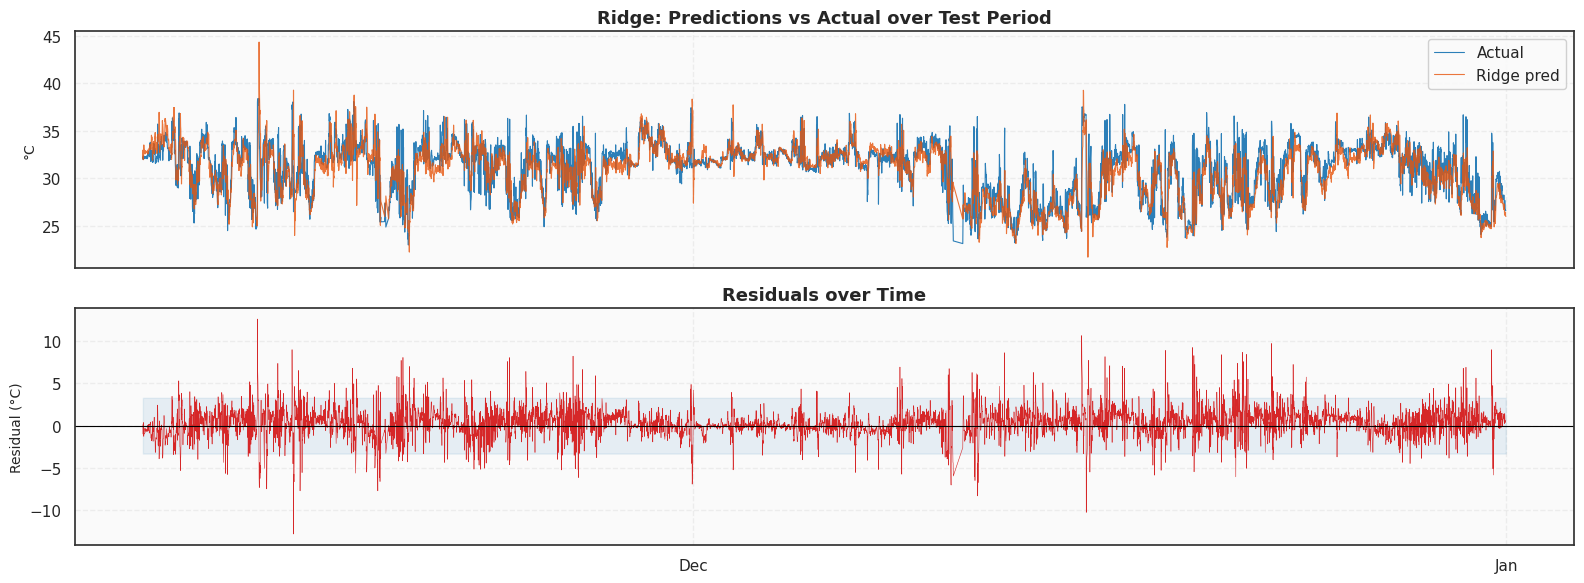

In [10]:
best_name = min(reg_results, key=lambda k: reg_results[k]["MAE"])
best = reg_results[best_name]

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

axes[0].plot(test_r["timestamp"], y_test, lw=0.8, label="Actual", color=PALETTE["primary"])
axes[0].plot(test_r["timestamp"], best["preds"], lw=0.8, alpha=0.8,
             label=f"{best_name} pred", color=PALETTE["accent"])
axes[0].set_ylabel("°C")
axes[0].set_title(f"{best_name}: Predictions vs Actual over Test Period")
axes[0].legend(loc="upper right")

axes[1].plot(test_r["timestamp"], best["residuals"], lw=0.4, color=PALETTE["danger"])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].fill_between(test_r["timestamp"],
                     -best["residuals"].std()*2,
                     best["residuals"].std()*2,
                     alpha=0.1, color=PALETTE["primary"])
axes[1].set_ylabel("Residual (°C)")
axes[1].set_title("Residuals over Time")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
plt.savefig("../figures/regression/07_error_over_time.png", dpi=150)
plt.show()

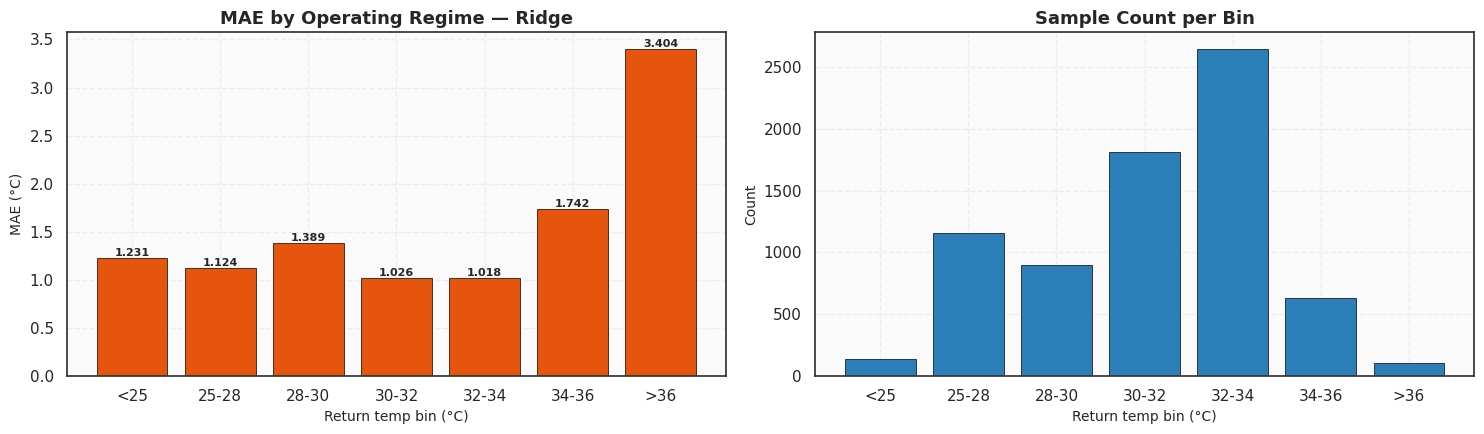

            mae     n
bin                  
<25    1.231102   138
25-28  1.124106  1159
28-30  1.388641   897
30-32  1.025994  1815
32-34  1.018313  2646
34-36  1.741742   635
>36    3.403932   111


In [11]:
# Bin test set by actual return temp and show MAE per bin
test_r_ = test_r.copy()
test_r_["pred"] = best["preds"]
test_r_["abs_err"] = np.abs(test_r_["y_next"] - test_r_["pred"])
test_r_["bin"] = pd.cut(test_r_["y_next"],
                        bins=[0, 25, 28, 30, 32, 34, 36, 100],
                        labels=["<25", "25-28", "28-30", "30-32", "32-34", "34-36", ">36"])

bin_stats = test_r_.groupby("bin", observed=True).agg(
    mae=("abs_err", "mean"),
    n=("abs_err", "size"),
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

bars = axes[0].bar(range(len(bin_stats)), bin_stats["mae"],
                   color=PALETTE["accent"], edgecolor="black", linewidth=0.5)
axes[0].set_xticks(range(len(bin_stats)))
axes[0].set_xticklabels(bin_stats.index)
axes[0].set_xlabel("Return temp bin (°C)")
axes[0].set_ylabel("MAE (°C)")
axes[0].set_title(f"MAE by Operating Regime — {best_name}")
for bar, v in zip(bars, bin_stats["mae"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f"{v:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

axes[1].bar(range(len(bin_stats)), bin_stats["n"],
            color=PALETTE["primary"], edgecolor="black", linewidth=0.5)
axes[1].set_xticks(range(len(bin_stats)))
axes[1].set_xticklabels(bin_stats.index)
axes[1].set_xlabel("Return temp bin (°C)")
axes[1].set_ylabel("Count")
axes[1].set_title("Sample Count per Bin")

plt.tight_layout()
plt.savefig("../figures/regression/08_error_by_regime.png", dpi=150)
plt.show()

print(bin_stats)

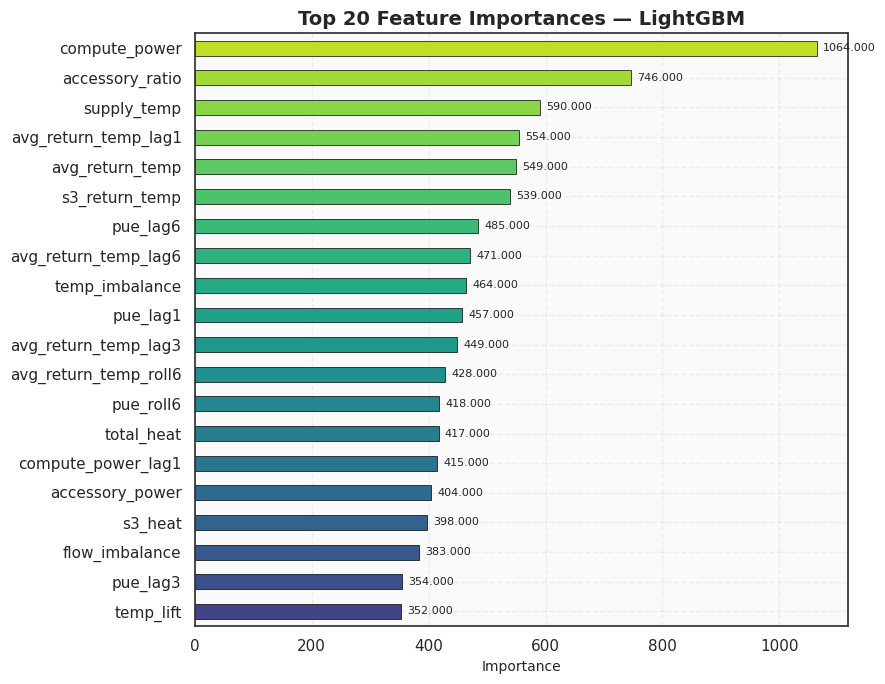

In [12]:
best_tree_name = None
for name in ["LightGBM", "XGBoost", "RandomForest"]:
    if hasattr(reg_results[name]["model"], "feature_importances_"):
        best_tree_name = name
        break

if best_tree_name:
    model = reg_results[best_tree_name]["model"]
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    imp = imp.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(9, 7))
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(imp)))[::-1]
    imp.plot(kind="barh", ax=ax, color=colors, edgecolor="black", linewidth=0.5)
    ax.invert_yaxis()
    ax.set_xlabel("Importance")
    ax.set_title(f"Top 20 Feature Importances — {best_tree_name}",
                 fontsize=14, fontweight="bold")
    for i, v in enumerate(imp.values):
        ax.text(v + max(imp)*0.01, i, f"{v:.3f}", va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig("../figures/regression/09_feature_importance.png", dpi=150)
    plt.show()

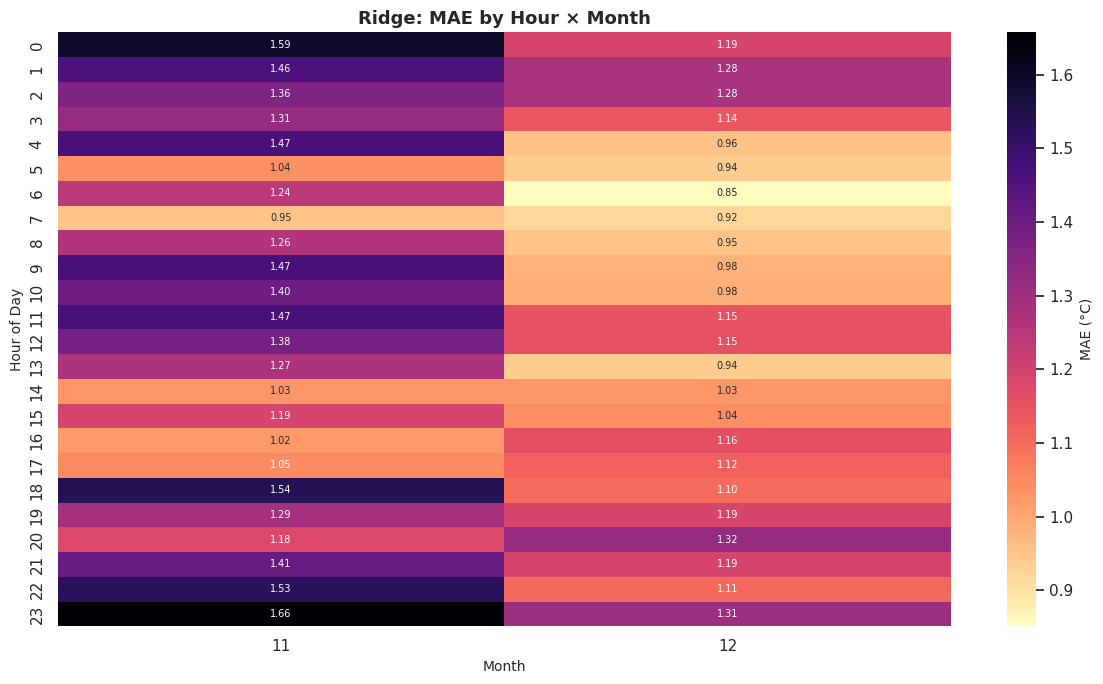

In [13]:
test_r_["hour"]  = test_r_["timestamp"].dt.hour
test_r_["month"] = test_r_["timestamp"].dt.month

pivot = test_r_.pivot_table(index="hour", columns="month",
                             values="abs_err", aggfunc="mean")

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, cmap="magma_r", annot=True, fmt=".2f",
            annot_kws={"size": 7}, cbar_kws={"label": "MAE (°C)"}, ax=ax)
ax.set_title(f"{best_name}: MAE by Hour × Month", fontsize=13, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Hour of Day")
plt.tight_layout()
plt.savefig("../figures/regression/10_error_heatmap.png", dpi=150)
plt.show()

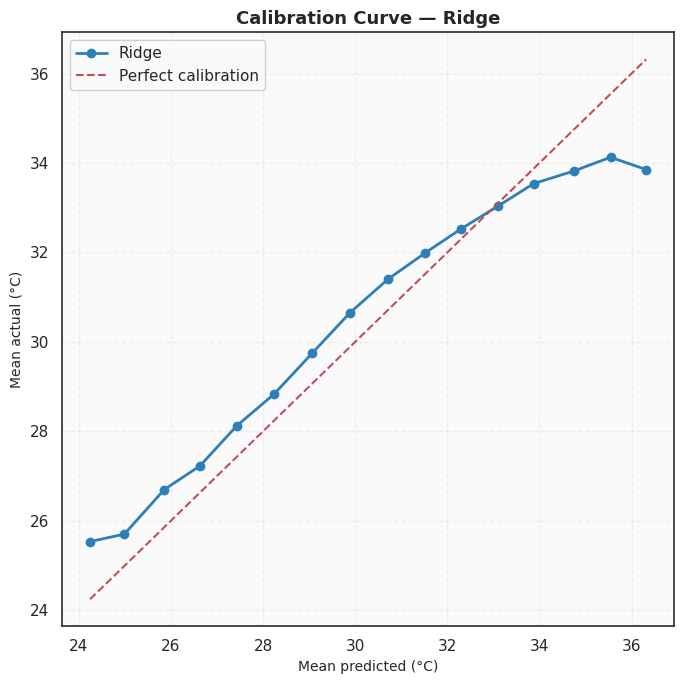

In [14]:
# Bin predicted values; plot mean actual per bin
bins = np.linspace(y_test.min(), y_test.max(), 20)
bin_idx = np.digitize(best["preds"], bins)

calib_x = []
calib_y = []
for i in range(1, len(bins)):
    mask = bin_idx == i
    if mask.sum() > 20:
        calib_x.append(best["preds"][mask].mean())
        calib_y.append(y_test[mask].mean())

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(calib_x, calib_y, "o-", color=PALETTE["primary"], lw=2, ms=6,
        label=best_name)
lims = [min(calib_x + calib_y), max(calib_x + calib_y)]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect calibration")
ax.set_xlabel("Mean predicted (°C)")
ax.set_ylabel("Mean actual (°C)")
ax.set_title(f"Calibration Curve — {best_name}")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/regression/11_calibration.png", dpi=150)
plt.show()

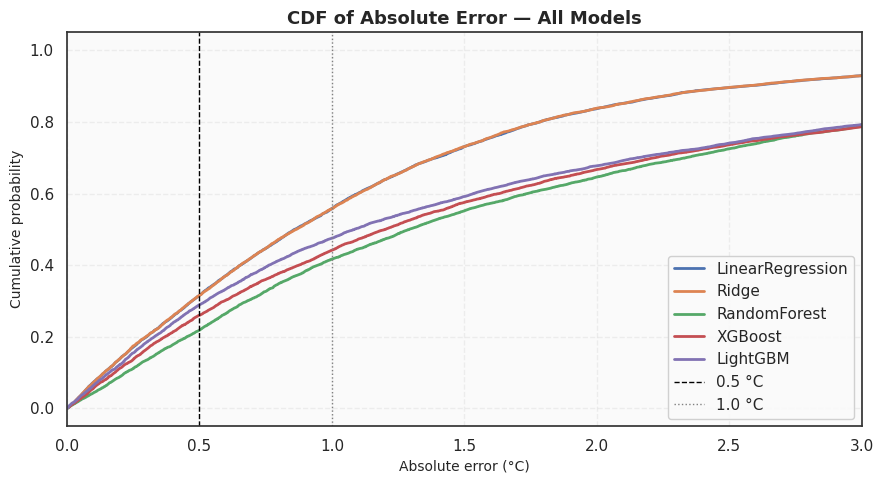

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

for name, r in reg_results.items():
    sorted_ae = np.sort(np.abs(r["residuals"]))
    cdf = np.arange(1, len(sorted_ae)+1) / len(sorted_ae)
    ax.plot(sorted_ae, cdf, lw=2, label=name)

ax.axvline(0.5, color="black", ls="--", lw=1, label="0.5 °C")
ax.axvline(1.0, color="gray", ls=":", lw=1, label="1.0 °C")
ax.set_xlabel("Absolute error (°C)")
ax.set_ylabel("Cumulative probability")
ax.set_title("CDF of Absolute Error — All Models")
ax.set_xlim(0, 3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../figures/regression/12_error_cdf.png", dpi=150)
plt.show()

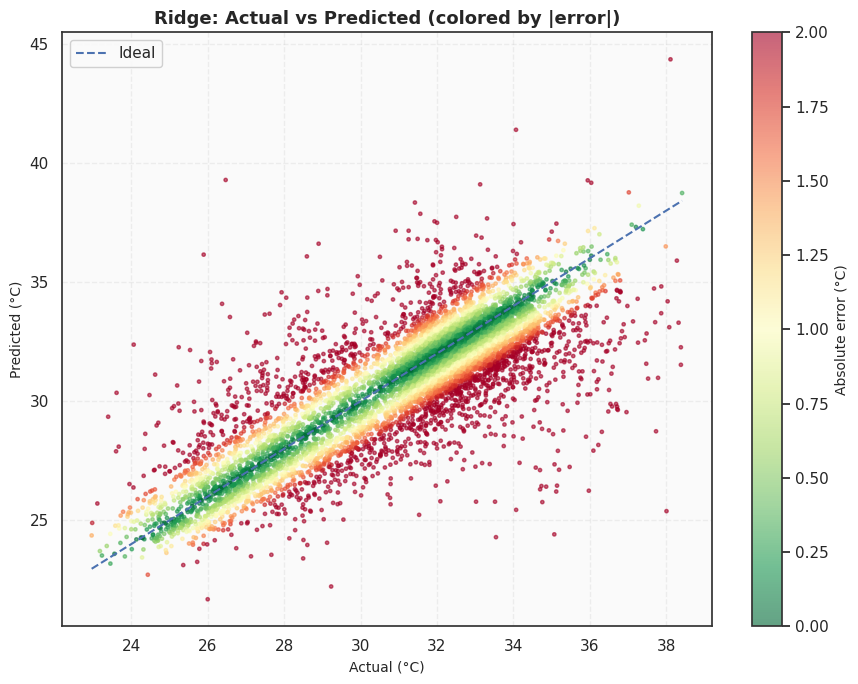

In [16]:
fig, ax = plt.subplots(figsize=(9, 7))

sc = ax.scatter(y_test, best["preds"],
                c=np.abs(best["residuals"]), cmap="RdYlGn_r",
                s=6, alpha=0.6, vmin=0, vmax=2)
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, "b--", lw=1.5, label="Ideal")
ax.set_xlabel("Actual (°C)")
ax.set_ylabel("Predicted (°C)")
ax.set_title(f"{best_name}: Actual vs Predicted (colored by |error|)",
             fontsize=13, fontweight="bold")
cb = fig.colorbar(sc, ax=ax)
cb.set_label("Absolute error (°C)")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/regression/13_pred_actual_colored.png", dpi=150)
plt.show()

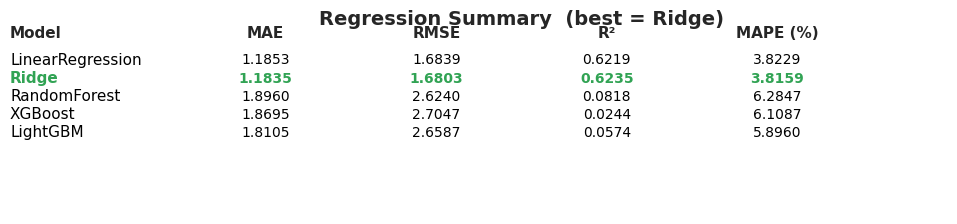

In [17]:
fig, ax = plt.subplots(figsize=(11, 0.6 + 0.35 * len(df_reg)))
ax.axis("off")

metrics_show = ["MAE", "RMSE", "R²", "MAPE (%)"]
n_metrics = len(metrics_show)

# Header
ax.text(-0.1, 1.0, "Model", fontsize=11, fontweight="bold", va="center")
for j, m in enumerate(metrics_show):
    ax.text((j+1)/(n_metrics+1), 1.0, m, fontsize=11, fontweight="bold",
            va="center", ha="center")

# Rows
y = 0.85
for name in df_reg.index:
    weight = "bold" if name == best_name else "normal"
    color = PALETTE["success"] if name == best_name else "black"

    ax.text(-0.1, y, name, fontsize=11, fontweight=weight,
            color=color, va="center")
    for j, m in enumerate(metrics_show):
        ax.text((j+1)/(n_metrics+1), y, f"{df_reg.loc[name, m]:.4f}",
                fontsize=10, va="center", ha="center",
                fontweight=weight, color=color)
    y -= 0.1

ax.set_title(f"Regression Summary  (best = {best_name})",
             fontsize=14, fontweight="bold")
plt.savefig("../figures/regression/14_summary_table.png", dpi=150)
plt.show()

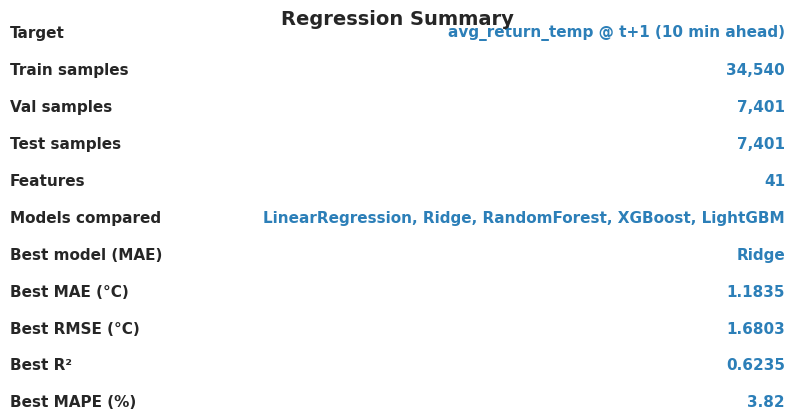

Target                 avg_return_temp @ t+1 (10 min ahead)
Train samples          34,540
Val samples            7,401
Test samples           7,401
Features               41
Models compared        LinearRegression, Ridge, RandomForest, XGBoost, LightGBM
Best model (MAE)       Ridge
Best MAE (°C)          1.1835
Best RMSE (°C)         1.6803
Best R²                0.6235
Best MAPE (%)          3.82


In [18]:
summary = {
    "Target":             target_col + " @ t+1 (10 min ahead)",
    "Train samples":      f"{len(train_r):,}",
    "Val samples":        f"{len(val_r):,}",
    "Test samples":       f"{len(test_r):,}",
    "Features":           f"{len(feature_cols)}",
    "Models compared":    ", ".join(reg_results.keys()),
    "Best model (MAE)":   best_name,
    "Best MAE (°C)":      f"{reg_results[best_name]['MAE']:.4f}",
    "Best RMSE (°C)":     f"{reg_results[best_name]['RMSE']:.4f}",
    "Best R²":            f"{reg_results[best_name]['R2']:.4f}",
    "Best MAPE (%)":      f"{reg_results[best_name]['MAPE']:.2f}",
}

fig, ax = plt.subplots(figsize=(10, 0.4 + 0.4 * len(summary)))
ax.axis("off")
y = 1.0
for k, v in summary.items():
    ax.text(0.0, y, k, fontsize=11, fontweight="bold", va="center")
    ax.text(1.0, y, str(v), fontsize=11, ha="right",
            color=PALETTE["primary"], fontweight="bold", va="center")
    y -= 0.1
ax.set_title("Regression Summary", fontsize=14, fontweight="bold")
plt.savefig("../figures/regression/15_summary.png", dpi=150)
plt.show()

for k, v in summary.items():
    print(f"{k:22s} {v}")

In [19]:
model_path = f"../models/best_regressor_{best_name}.pkl"
joblib.dump(reg_results[best_name]["model"], model_path)

with open("../models/regression_meta.json", "w") as f:
    json.dump({
        "best_model":     best_name,
        "target":         target_col + "_next",
        "feature_cols":   feature_cols,
        "test_MAE":       float(reg_results[best_name]["MAE"]),
        "test_RMSE":      float(reg_results[best_name]["RMSE"]),
        "test_R2":        float(reg_results[best_name]["R2"]),
        "test_MAPE":      float(reg_results[best_name]["MAPE"]),
    }, f, indent=2)

print("✓ Saved:")
print(f"   {model_path}")
print("   ../models/regression_meta.json")

✓ Saved:
   ../models/best_regressor_Ridge.pkl
   ../models/regression_meta.json


In [20]:
paper = {
    "target": "facility accessory power (MW)",
    "test_MAE": 0.026,
    "test_WAPE": 4.0,
    "test_R2": 0.79,
}

print("=== Comparison with Jadhav & Liu (2026) ===")
print(f"Paper forecast target:    {paper['target']}")
print(f"Paper test MAE:           {paper['test_MAE']:.3f} MW")
print(f"Paper WAPE:               {paper['test_WAPE']:.1f} %")
print(f"Paper R²:                 {paper['test_R2']:.2f}")
print()
print(f"Your forecast target:     {target_col} @ t+1 (°C)")
print(f"Your test MAE:            {reg_results[best_name]['MAE']:.4f} °C")
print(f"Your MAPE:                {reg_results[best_name]['MAPE']:.2f} %")
print(f"Your R²:                  {reg_results[best_name]['R2']:.4f}")
print()
print("Direct comparison is not apples-to-apples (different targets),")
print("but both demonstrate sub-5% relative error and strong R² on Frontier telemetry.")

=== Comparison with Jadhav & Liu (2026) ===
Paper forecast target:    facility accessory power (MW)
Paper test MAE:           0.026 MW
Paper WAPE:               4.0 %
Paper R²:                 0.79

Your forecast target:     avg_return_temp @ t+1 (°C)
Your test MAE:            1.1835 °C
Your MAPE:                3.82 %
Your R²:                  0.6235

Direct comparison is not apples-to-apples (different targets),
but both demonstrate sub-5% relative error and strong R² on Frontier telemetry.
